# **EJERCICIO 1**

In [2]:
import numpy as np

# Datos
x_data = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
A_data = np.array([0.68, 0.65, 0.64, 0.61, 0.58, 0.59, 0.53, 0.55, 0.52, 0.50, 0.48])

# Parámetros
a, b, n = 0, 10, 5
h = (b - a) / n

# Crear puntos medios
midpoints = np.linspace(a + h/2, b - h/2, n)  # puntos medios exactos

# Interpolar linealmente para obtener A en puntos medios
A_mid = np.interp(midpoints, x_data, A_data)

# Calcular volumen
volumen = h * np.sum(A_mid)

print("Puntos medios:", midpoints)
print("Áreas en puntos medios:", A_mid)
print(f"Volumen estimado: {volumen:.2f} m³")

Puntos medios: [1. 3. 5. 7. 9.]
Áreas en puntos medios: [0.65 0.61 0.59 0.55 0.5 ]
Volumen estimado: 5.80 m³


# **EJERCICIO 2**

In [1]:
def volumen_piramide(L, h):
    """
    Volumen de una pirámide de base cuadrada de lado L y altura h
    usando el método de secciones transversales: V = (L^2 * h) / 3
    """
    return (L**2 * h) / 3

# Ejemplos
print(volumen_piramide(4, 9))      # 48.0
print(volumen_piramide(2.5, 7))    # 14.583333333333334

48.0
14.583333333333334


# **EJERCICIO 3**

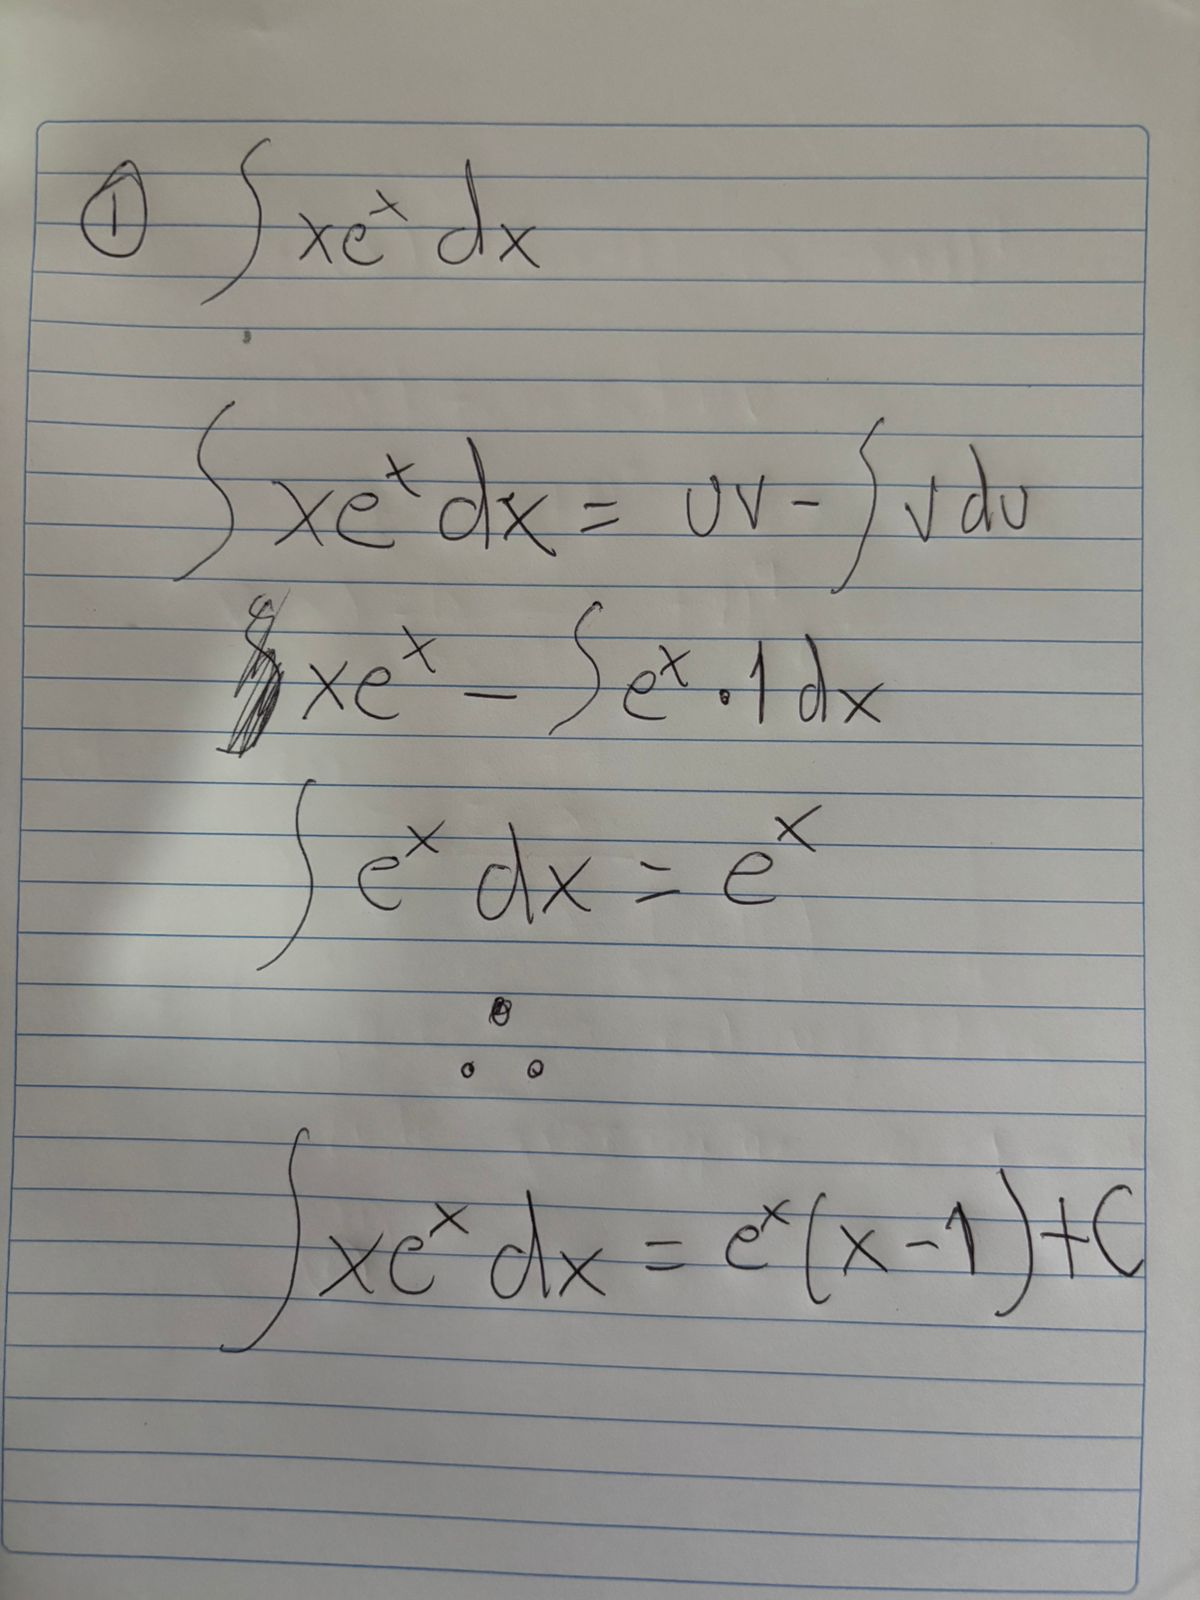

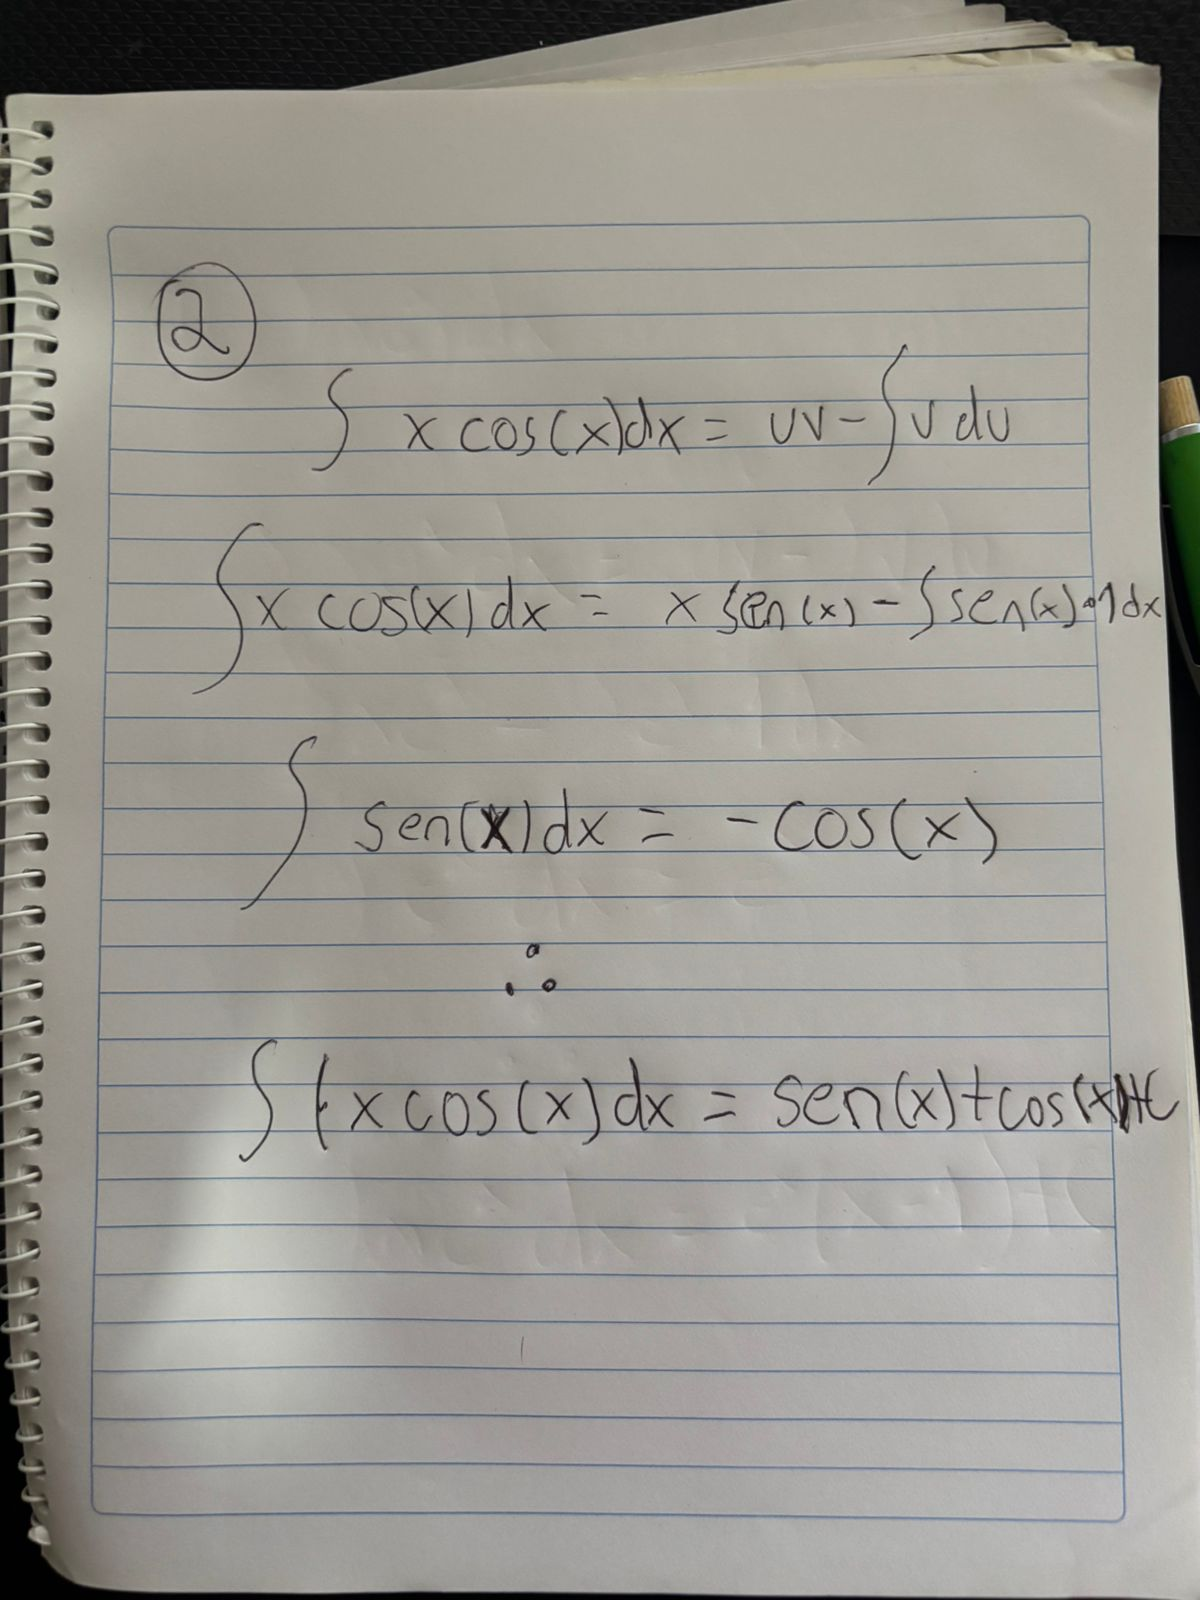

# **EJERCICIO 4**

In [ ]:
# INSPIRACIÓN: https://youtu.be/37_y4V_eeio?si=5IcTRtBSxJKvsdPE

import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
import time


def f(x):
    # Misma función del notebook del video
    return (1/3)*x**2 + 1

xi, xf = -4, 4
A_exacta = 2 * ((1/9)*4**3 + 4)
print("Área exacta:", A_exacta)


# 2. Sumas de Riemann

def riemann_izq(f, xi, xf, n):
    """
    Suma de Riemann por la izquierda.
    n = número de subintervalos
    """
    x = np.linspace(xi, xf, n+1)   # n subintervalos => n+1 puntos
    h = (xf - xi) / n
    fx = f(x[:-1])                 # usa extremos izquierdos
    A = np.sum(fx) * h
    return A

def riemann_der(f, xi, xf, n):
    """
    Suma de Riemann por la derecha.
    """
    x = np.linspace(xi, xf, n+1)
    h = (xf - xi) / n
    fx = f(x[1:])                  # usa extremos derechos
    A = np.sum(fx) * h
    return A

def riemann_med(f, xi, xf, n):
    """
    Suma de Riemann por puntos medios.
    """
    x = np.linspace(xi, xf, n+1)
    h = (xf - xi) / n
    mids = (x[:-1] + x[1:]) / 2    # puntos medios
    fx = f(mids)
    A = np.sum(fx) * h
    return A

# 3. Regla de Simpson

def simpson(f, xi, xf, n):
    """
    Regla de Simpson compuesta.
    IMPORTANTE: n debe ser PAR.
    """
    if n % 2 == 1:
        raise ValueError("Para Simpson, n debe ser par.")
    x = np.linspace(xi, xf, n+1)
    h = (xf - xi) / n
    fx = f(x)
    A = h/3 * (fx[0] + fx[-1] + 4*np.sum(fx[1:-1:2]) + 2*np.sum(fx[2:-1:2]))
    return A



# 4. Experimentos para varios n

n_values = [4, 8, 16, 32, 64, 128]

tabla = []
errores_riemann = []
errores_simpson = []

for n in n_values:
    # Sumas de Riemann
    t0 = time.perf_counter()
    A_izq = riemann_izq(f, xi, xf, n)
    A_der = riemann_der(f, xi, xf, n)
    A_med = riemann_med(f, xi, xf, n)
    t1 = time.perf_counter()
    tiempo_riemann = t1 - t0

    err_izq = abs(A_exacta - A_izq)
    err_der = abs(A_exacta - A_der)
    err_med = abs(A_exacta - A_med)

    # Simpson
    t2 = time.perf_counter()
    A_simp = simpson(f, xi, xf, n)   # n ya es par en la lista
    t3 = time.perf_counter()
    tiempo_simp = t3 - t2

    err_simp = abs(A_exacta - A_simp)

    # Guardamos errores representativos para la gráfica
    errores_riemann.append(err_med)      # usamos la de punto medio
    errores_simpson.append(err_simp)

    # Fila de la tabla
    tabla.append([
        n,
        A_izq, err_izq,
        A_der, err_der,
        A_med, err_med,
        A_simp, err_simp,
        tiempo_riemann,
        tiempo_simp
    ])

# Imprimir tabla comparativa
headers = ["n",
           "A_izq", "Error_izq",
           "A_der", "Error_der",
           "A_med", "Error_med",
           "A_Simpson", "Error_Simpson",
           "t_Riemann (s)", "t_Simpson (s)"]

print(tabulate(tabla, headers=headers, floatfmt=".8f"))




Área exacta: 22.22222222222222
  n        A_izq    Error_izq        A_der    Error_der        A_med    Error_med    A_Simpson    Error_Simpson    t_Riemann (s)    t_Simpson (s)
---  -----------  -----------  -----------  -----------  -----------  -----------  -----------  ---------------  ---------------  ---------------
  4  24.00000000   1.77777778  24.00000000   1.77777778  21.33333333   0.88888889  22.22222222       0.00000000       0.00030862       0.00006286
  8  22.66666667   0.44444444  22.66666667   0.44444444  22.00000000   0.22222222  22.22222222       0.00000000       0.00015811       0.00005374
 16  22.33333333   0.11111111  22.33333333   0.11111111  22.16666667   0.05555556  22.22222222       0.00000000       0.00013280       0.00005146
 32  22.25000000   0.02777778  22.25000000   0.02777778  22.20833333   0.01388889  22.22222222       0.00000000       0.00015276       0.00005147
 64  22.22916667   0.00694444  22.22916667   0.00694444  22.21875000   0.00347222  22.2222222

Una tabla donde, para cada
𝑛
n:

Las tres aproximaciones de Riemann (izquierda, derecha, medio) y sus errores.

La aproximación de Simpson y su error.

Tiempos de ejecución aproximados para Riemann y Simpson.

Una gráfica log–log de error vs
𝑛
n:

La curva de Simpson se mantiene extremadamente cerca de cero (en este ejemplo, es exacta porque la función es un polinomio de grado 2).

Las Sumas de Riemann mejoran el error al aumentar
𝑛
n, pero nunca alcanzan la precisión de Simpson para el mismo número de subintervalos.

Conclusión que podés escribir en tu trabajo:

Para la función
𝑓
(
𝑥
)
=
1
3
𝑥
2
+
1
f(x)=
3
1
	​

x
2
+1 en
[
−
4
,
4
]
[−4,4], la regla de Simpson obtiene el área exacta con errores numéricos prácticamente nulos, mientras que las Sumas de Riemann (incluso con punto medio) requieren valores grandes de
𝑛
n para acercarse.
El tiempo de cómputo de Simpson es del mismo orden que el de las Sumas de Riemann, por lo que, en términos de rendimiento (precisión vs costo computacional), la regla de Simpson resulta claramente más eficiente.